# Introduction to DEA Land Cover <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with the `DEA Sandbox` environment
* **Products used:** [ga_ls_landcover_class_cyear_3](https://explorer.dea.ga.gov.au/ga_ls_landcover_class_cyear_3)

## Background

Land cover is the physical surface of the Earth, including trees, shrubs, grasses, soils, exposed rocks, water bodies, plantations, crops and built structures.
Land cover changes for many reasons, including seasonal weather, severe weather events, and human activities.
Remote sensing data recorded over time allows the observation of land cover dynamics.
DEA Land Cover aims to provide a national land cover data set that places current land cover status and changes into a historical context at a national, regional and local scale.

### What this product offers

[Digital Earth Australia Land Cover (DEA Land Cover)](https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat) is a continental dataset that maps  annual land cover classifications for Australia from 1988 to the present. 
DEA Land Cover is at a 30 m resolution, meaning each pixel represents a 30 m × 30 m area on the ground. 
Each pixel shows the predominant land cover condition for the selected year.
The product combines Landsat satellite data and related data products from Geoscience Australia's [Digital Earth Australia](https://www.dea.ga.gov.au/) program. 

The classification system used in DEA Land Cover follows the Food and Agriculture Organization of the United Nations [land cover classification taxonomy](https://www.fao.org/land-water/land/land-governance/land-resources-planning-toolbox/category/details/en/c/1036361/), allowing for comparison and integration with other national and international datasets. 
The product defines six base land cover classes (Level 3), seven land cover environmental descriptors, and a final land cover classification (Level 4) that combines both base classes and environmental descriptors.
More information about each class can be found further down in this notebook (see **Plotting data**), and on the [DEA Land Cover product details](https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat) page.

### Applications

DEA Land Cover allows users to analyse land cover over a range of spatial, temporal and thematic scales. 
Scientists, resource managers and policymakers can use the product to support environmental monitoring, emergency management, sustainable natural resource management, and more.
Specific examples include: 

* **Environmental monitoring:** ecosystem mapping, carbon dynamics, erosion management 
* **Primary industries:** understanding crop responses to water availability, understanding and mitigating impact of drought, monitoring vegetation change
* **Community interests:** mapping urban expansion, mapping impacts of natural disasters, bushfire recovery.

### Publications

* Lucas R, Mueller N, Siggins A, Owers C, Clewley D, Bunting P, Kooymans C, Tissott B, Lewis B, Lymburner L, Metternicht G (2019) 'Land Cover Mapping using Digital Earth Australia', <em>Data</em>, 4(4):143, doi: [10.3390/data4040143](https://www.mdpi.com/2306-5729/4/4/143/htm).
* Owers C, Lucas R, Clewley D, Planque C, Punalekar S, Tissott B, Chua S, Bunting P, Mueller N, Metternicht G (2021) 'Living Earth: Implementing national standardised land cover classification systems for Earth Observation in support of sustainable development', <em>Big Earth Data</em>, 5(3):368-390, doi:[10.1080/20964471.2021.1948179](https://www.tandfonline.com/doi/full/10.1080/20964471.2021.1948179?scroll=top&needAccess=true).
* Metternicht G, Mueller N, Lucas R, 'Digital Earth for Sustainable Development Goals', <em>Manual of Digital Earth</em>, pp 443 - 471, Springer Singapore. [https://doi.org/10.1007/978-981-32-9915-3_13](https://doi.org/10.1007/978-981-32-9915-3_13).


## Description
This notebook will demonstrate how to load and visualise DEA Land Cover data using Digital Earth Australia. Topics covered include:

1. Inspecting available measurements in DEA Land Cover.
2. Choosing and loading DEA Land Cover data for an area of interest.
3. Plotting DEA Land Cover data.

<div class="alert alert-info">
    
**Note:** Visit the [DEA Land Cover product documentation](https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat) for detailed technical information including methods, quality, and data access.
To explore DEA Land Cover on an interactive map, [visit DEA Maps](https://maps.dea.ga.gov.au/story/DEALandCover).

</div>

***

## Getting started

To run this analysis, run all the cells in the notebook starting with the 'Load packages' cell. 

### Load packages
Load key Python packages and supporting functions for the analysis.

In [1]:
%matplotlib inline

import sys

import datacube
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(1, "../Tools/")
from dea_tools.plotting import rgb, display_map
from dea_tools.landcover import plot_land_cover
from matplotlib import colors as mcolours

### Connect to the datacube

Connect to the datacube database, which provides functionality for loading and displaying stored Earth observation data.

In [2]:
dc = datacube.Datacube(app="DEA_Land_Cover")

### View measurements list

We can generate a table listing all of the measurements in DEA Land Cover using the `dc.list_measurements()` function.
The table also shows information about measurement data types, nodata values, and aliases. 

In [3]:
product = "ga_ls_landcover_class_cyear_3"

measurements = dc.list_measurements()
measurements.loc[product]

,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
level3,level3,uint8,1,255,NaN,NaN
level4,level4,uint8,1,255,[full_classification],NaN


## Select and view your study area

**If running the notebook for the first time,** keep the default settings below.
This will demonstrate how the analysis works and provide meaningful results.
The following example loads land cover data for Broome, Western Australia.

In [4]:
# Coordinates for Broome, Western Australia
lat = -18.10
lon = 122.32
lat_buffer = 0.18
lon_buffer = 0.18

# Combine central coordinates with buffer values to create the latitude and longitude range for the analysis
lat_range = (lat - lat_buffer, lat + lat_buffer)
lon_range = (lon - lon_buffer, lon + lon_buffer)

# Set the range of dates for the analysis
time_range = ("2017", "2020")

The following cell will display the selected area on an interactive map.
You can zoom in and out to better understand the area you'll be analysing. 
Clicking on any point on the map will reveal that point's latitude and longitude coordinates.

In [5]:
display_map(x=lon_range, y=lat_range)

## Load and view DEA Land Cover data 
The following cell will load data for the `lat_range`, `lon_range` and `time_range` we defined above.
We can do this using the `dc.load()` function. 

> **Note:** The following cell loads all available measurements in DEA Land Cover, however, the query can be adapted to only load measurements of interest.

In [6]:
# Create the 'query' dictionary object, which contains the longitudes, latitudes and time defined above
query = {
    "y": lat_range,
    "x": lon_range,
    "time": time_range,
}

# Load DEA Land Cover data from the datacube
lc = dc.load(
    product="ga_ls_landcover_class_cyear_3",
    output_crs="EPSG:3577",
    measurements=[
        "level3",
        "level4"
    ],
    resolution=(-30, 30),
    **query
)

We can now view the data. 
The measurements listed under `Data variables` should match the measurements listed in the above query.

More information on interpreting `xarray.Dataset` results can be found in our [Beginner's guide](../Beginners_guide/04_Loading_data.ipynb).

In [7]:
lc

<xarray.Dataset> Size: 16MB
Dimensions:      (time: 4, y: 1422, x: 1367)
Coordinates:
  * time         (time) datetime64[ns] 32B 2017-07-02T11:59:59.999999 ... 202...
  * y            (y) float64 11kB -1.951e+06 -1.951e+06 ... -1.993e+06
  * x            (x) float64 11kB -1.044e+06 -1.044e+06 ... -1.003e+06
    spatial_ref  int32 4B 3577
Data variables:
    level3       (time, y, x) uint8 8MB 220 220 220 220 220 ... 112 112 112 112
    level4       (time, y, x) uint8 8MB 101 101 101 101 101 ... 34 34 34 34 34
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

## Plotting data

The following section will show you how to plot DEA Land Cover data using two different methods: the `plot_layer()` function that allows you to define your own colour map, and the `plot_land_cover()` function that uses DEA's standard colour maps. 

### Level 3 visualisation 

The Level 3 classification contains six base classes: 

* <strong>111: Cultivated Terrestrial Vegetation</strong>  
Cultivated vegetation is vegetation that has been changed by human influence, such as planted crops or improved pasture. This is different from areas left to minor grazing or fallow.
* <strong>112: Natural Terrestrial Vegetation</strong>  
Natural vegetation is vegetation that has not been changed by human influence. This includes native forests as well as pastures or paddocks left unchanged for the year. It does not identify whether the vegetation is native or otherwise.
* <strong>124: Natural Aquatic Vegetation</strong>  
Aquatic vegetation is vegetation that gets regularly inundated with water.  Natural Aquatic Vegetation is generally associated with swamps, fens, flooded forests, saltmarshes, or mangroves. Only mangroves are included in the current release.
* <strong>215: Artificial Surface</strong>  
Artificial surfaces are human-made, unvegetated areas. This includes the roofs of houses, concrete areas, road surfaces and other similar surfaces that we associate with civilisation.
* <strong>216: Natural Bare Surface</strong>  
Natural bare surface is mostly soil. It is very likely that there is still vegetation in the area, but it is dominated by soil.
* <strong>220: Water</strong>  
Water captures terrestrial and coastal open water such as dams, lakes, large rivers and the coastal and near-shore zone. 

To plot the `level3` data, we will use the `plot_layer()` function. 
The `plot_layer()` function allows you to define your own colour map as shown in the cell below. 
The keys respond to the Level 3 classifications, and the values are colour specifications (red, green, blue, alpha) and labels to be used in the legend.

In [8]:
# Define a colour scheme for the Level 3
LEVEL3_COLOUR_SCHEME = {
    111: (172, 188, 45, 255, "Cultivated terrestrial vegetation"),
    112: (14, 121, 18, 255, "Natural terrestrial vegetation"),
    124: (30, 191, 121, 255, "Natural aquatic vegetation"),
    215: (218, 92, 105, 255, "Artificial surface"),
    216: (243, 171, 105, 255, "Natural bare surface"),
    220: (77, 159, 220, 255, "Water"),
    255: (255, 255, 255, 255, "No Data"),
}
 

The following cell defines the `plot_layer()` function which takes DEA Land Cover data and a colour map as arguments.

In [9]:
# Plot layer from colour map

def plot_layer(colours, data):
    colour_arr = []
    for key, value in colours.items():
        colour_arr.append(np.array(value[:-1]) / 255)
 
    cmap = mcolours.ListedColormap(colour_arr)
    bounds = list(colours)
    bounds.append(256) # add upper bound to make sure highest value (255) included in last colour bin
    norm = mcolours.BoundaryNorm(np.array(bounds) - 0.1, cmap.N)
    lables = {'ticks' : [111,112,124,215,216,220,255],}

    if len(data.time) == 1: 
        # Plot the provided layer
        im = data.isel(time=0).plot(
        cmap=cmap, norm=norm, add_colorbar=True, size=5, cbar_kwargs=lables
        )

    else:
        # Plot the provided layer
        im = data.plot(
        cmap=cmap, norm=norm, add_colorbar=True, col="time", col_wrap=4, size=5, cbar_kwargs=lables
        )
 
    return im

We can now plot the data:

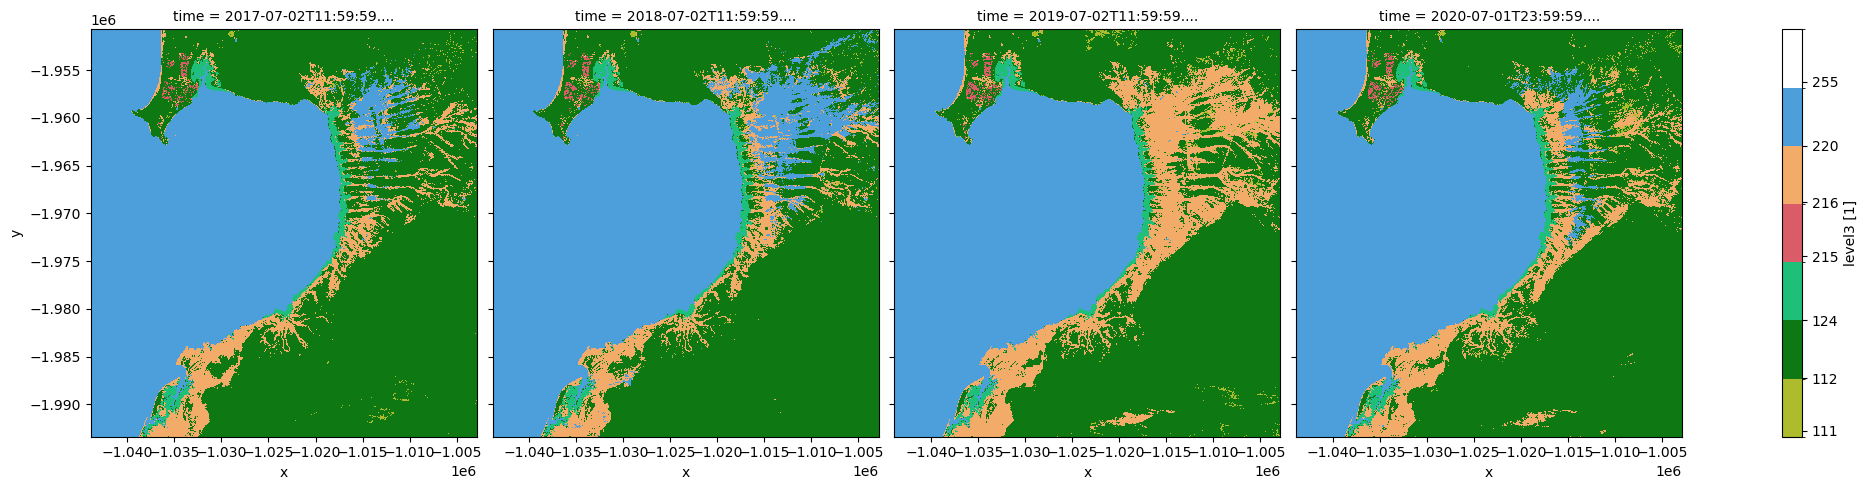

In [10]:
plot_layer(LEVEL3_COLOUR_SCHEME, lc.level3)

In the following sections, we will plot data using the `plot_land_cover()` function. More details about the function can be found in [landcover.py](../Tools/dea_tools/landcover.py).

### Visualising environmental descriptors 

There are seven environmental descriptors that can be generated from the DEA Land Cover classes: lifeform, vegetation cover, water seasonality, water state, intertidal area, water persistence, and bare gradation. 

The following section provides more detail about each environmental descriptor, then uses the `plot_land_cover()` function to visualise them. 

#### Lifeform

Lifeform describes the predominant vegetation type in vegetated areas.
It is categorised as follows: 

* Not applicable (such as no data or not vegetated) 
* Herbaceous vegetation (grasses, forbs)
* Woody vegetation (trees, shrubs)

Lifeform provides detail to the following Level 3 classes: Cultivated Terrestrial Vegetation (111), Natural Terrestrial Vegetation (112), and Natural Aquatic Vegetation (124).

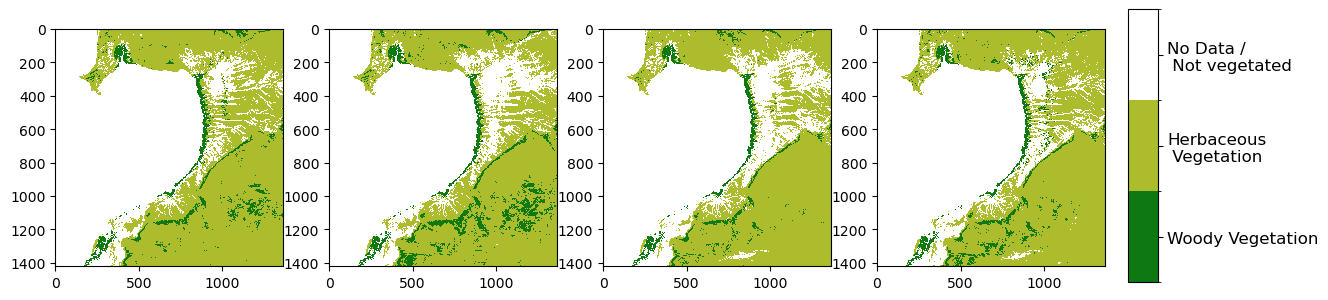

In [11]:
plot_land_cover(lc.level4, measurement='lifeform')

#### Vegetation cover

Vegetation cover describes the percentage of cover in vegetated areas. 
It is categorised as follows: 

* Not applicable (such as in bare areas)
* Scattered (1 to 4%)
* Sparse (4 to 15%)
* Open (15 to 40%)
* Open (40 to 65%)  
* Closed (>65%)  

Vegetation cover provides detail to the following Level 3 classes: Cultivated Terrestrial Vegetation (111), Natural Terrestrial Vegetation (112), and Natural Aquatic Vegetation (124). 

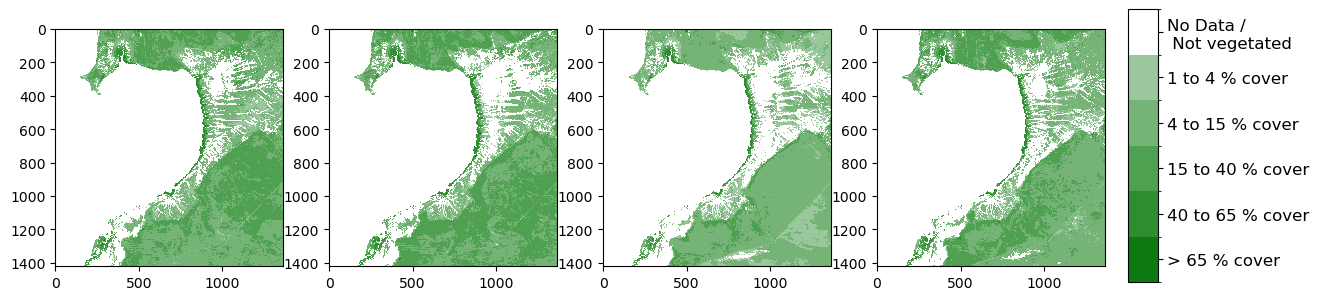

In [12]:
plot_land_cover(lc.level4, measurement='vegetation_cover')

#### Water seasonality

Water seasonality describes the length of time an aquatic vegetated area was measured as being inundated.
It is categorised as follows: 

* Not applicable (such as no data or not an aquatic environment)
* Temporary or seasonal (< 3 months) 
* Semi-permanent or permanent (> 3 months)  
 

Water seasonality provides detail to the following Level 3 class: Natural Aquatic Vegetation (124).

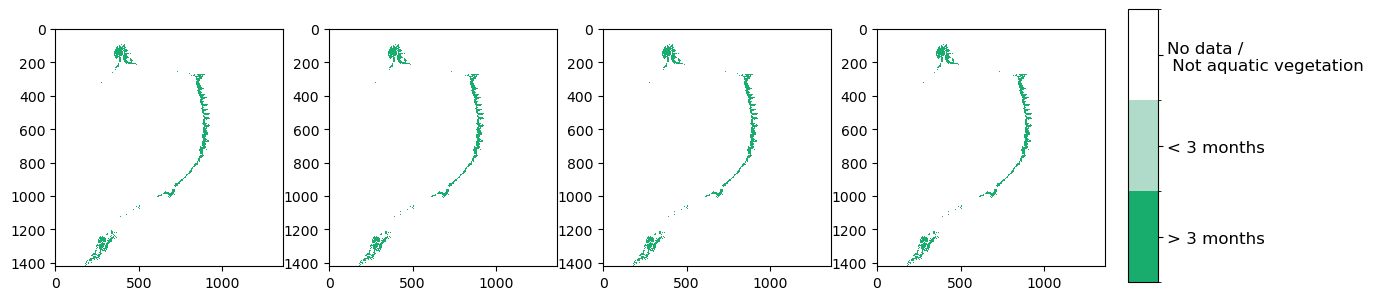

In [13]:
plot_land_cover(lc.level4, measurement='water_seasonality')

As water seasonlity only relates to wet vegetation, it's hard to see the seasonality changes at this scale. 
We can easily 'zoom in' to see more detail. 

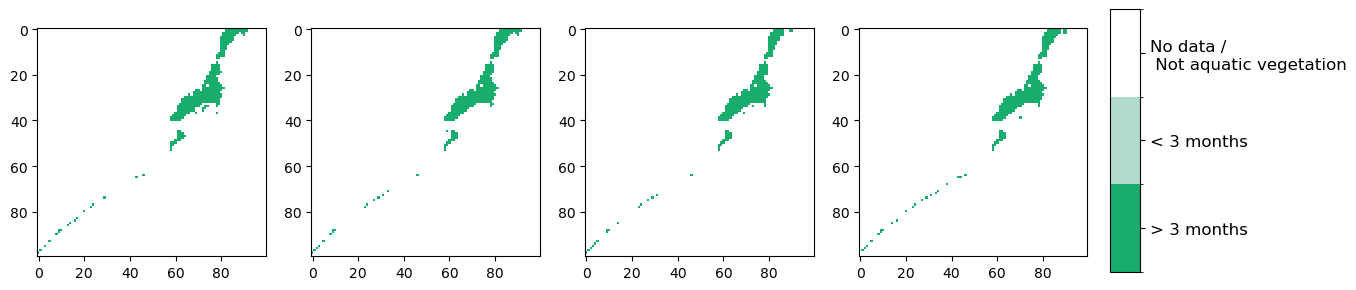

In [14]:
plot_land_cover(lc.level4[:, 200:300, 300:400], measurement='water_seasonality')

#### Water state

Water state describes whether the detected water is snow, ice or liquid water. 
It is categorised as follows:

* Not applicable (such as no data or not water)
* Water 
    
Water state provides detail to the following Level 3 class: Water (220).

> **Note:** Only liquid water is described in this release.

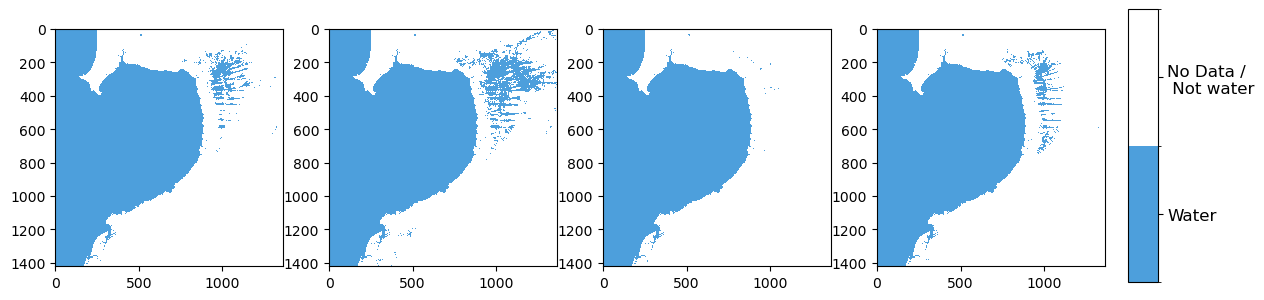

In [15]:
plot_land_cover(lc.level4, measurement='water_state')

#### Intertidal 

Intertidal delineates the intertidal zone.
It is categorised as follows:

* Not applicable (such as no data or not intertidal) 
* Intertidal zone  

Intertidal provides detail to the following Level 3 class: Water (220).

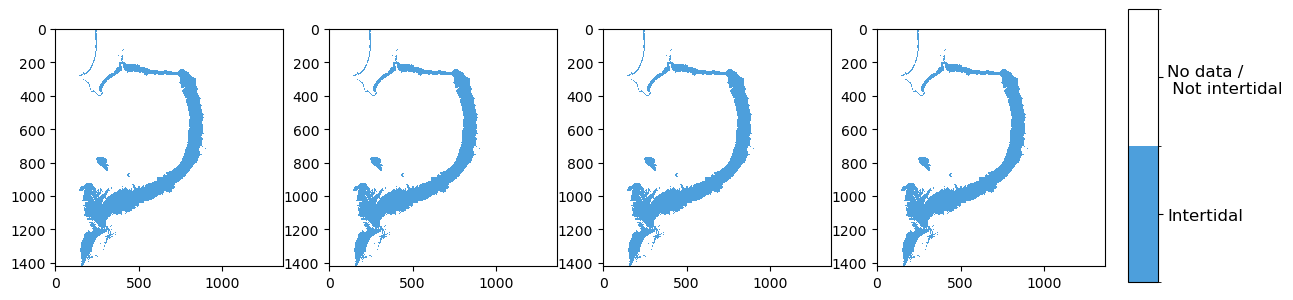

In [16]:
plot_land_cover(lc.level4, measurement='intertidal')

#### Water persistence 

Water persistence describes the number of months a water body contains water.
It is categorised as follows:

* Not applicable (such as no data or not water)
* 1-3 months
* 4-6 months
* 7-9 months
* _>_ 9 months  

Water persistence provides detail to the following Level 3 class: Water (220).

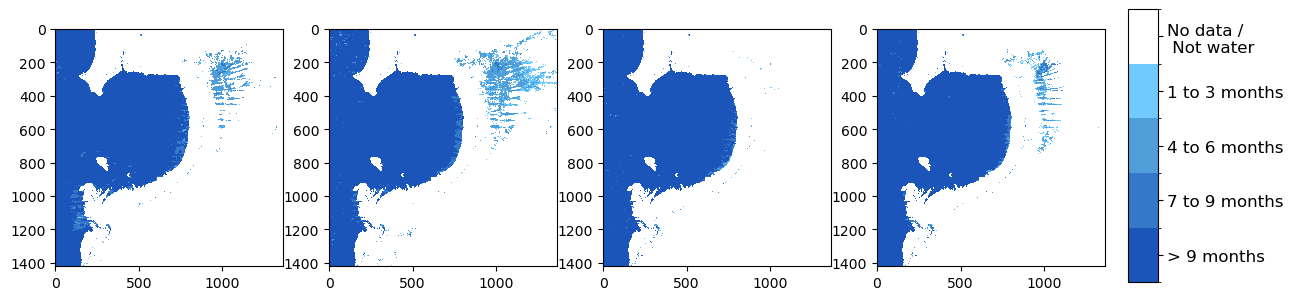

In [17]:
plot_land_cover(lc.level4, measurement='water_persistence')

#### Bare gradation

Bare gradation describes the percentage of bare cover in naturally bare areas.
It is categorised as follows: 

* Not applicable (such as no data or not a natural bare surface)
* Bare areas, unvegetated (> 60 % bare)
* Very sparsely vegetated (20 to 60 % bare) 
* Sparsely vegetated (< 20 % bare) 

Bare gradation provides detail to the following Level 3 class: Natural Bare Surface (216).

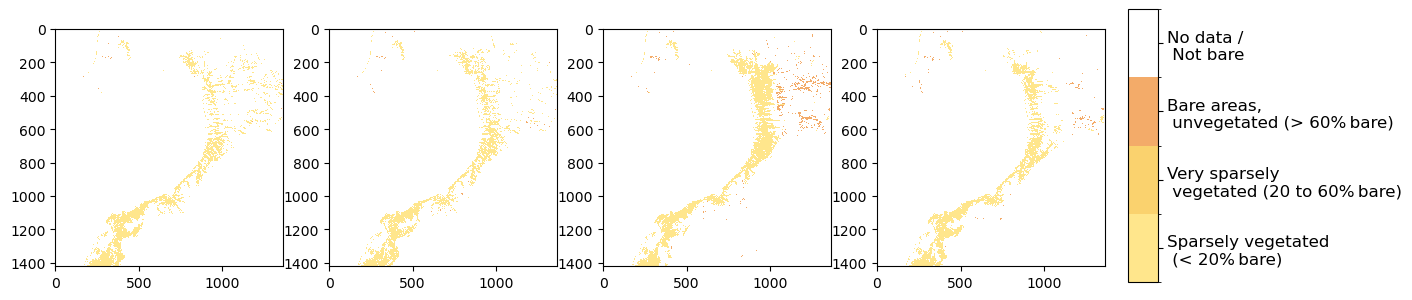

In [18]:
plot_land_cover(lc.level4, measurement='bare_gradation')

### Level 4 visualisation

The Level 4 classification combines the Level 3 classes with the seven environmental descriptors. 
For the full list of classification values, visit [DEA Land Cover product details](https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat).

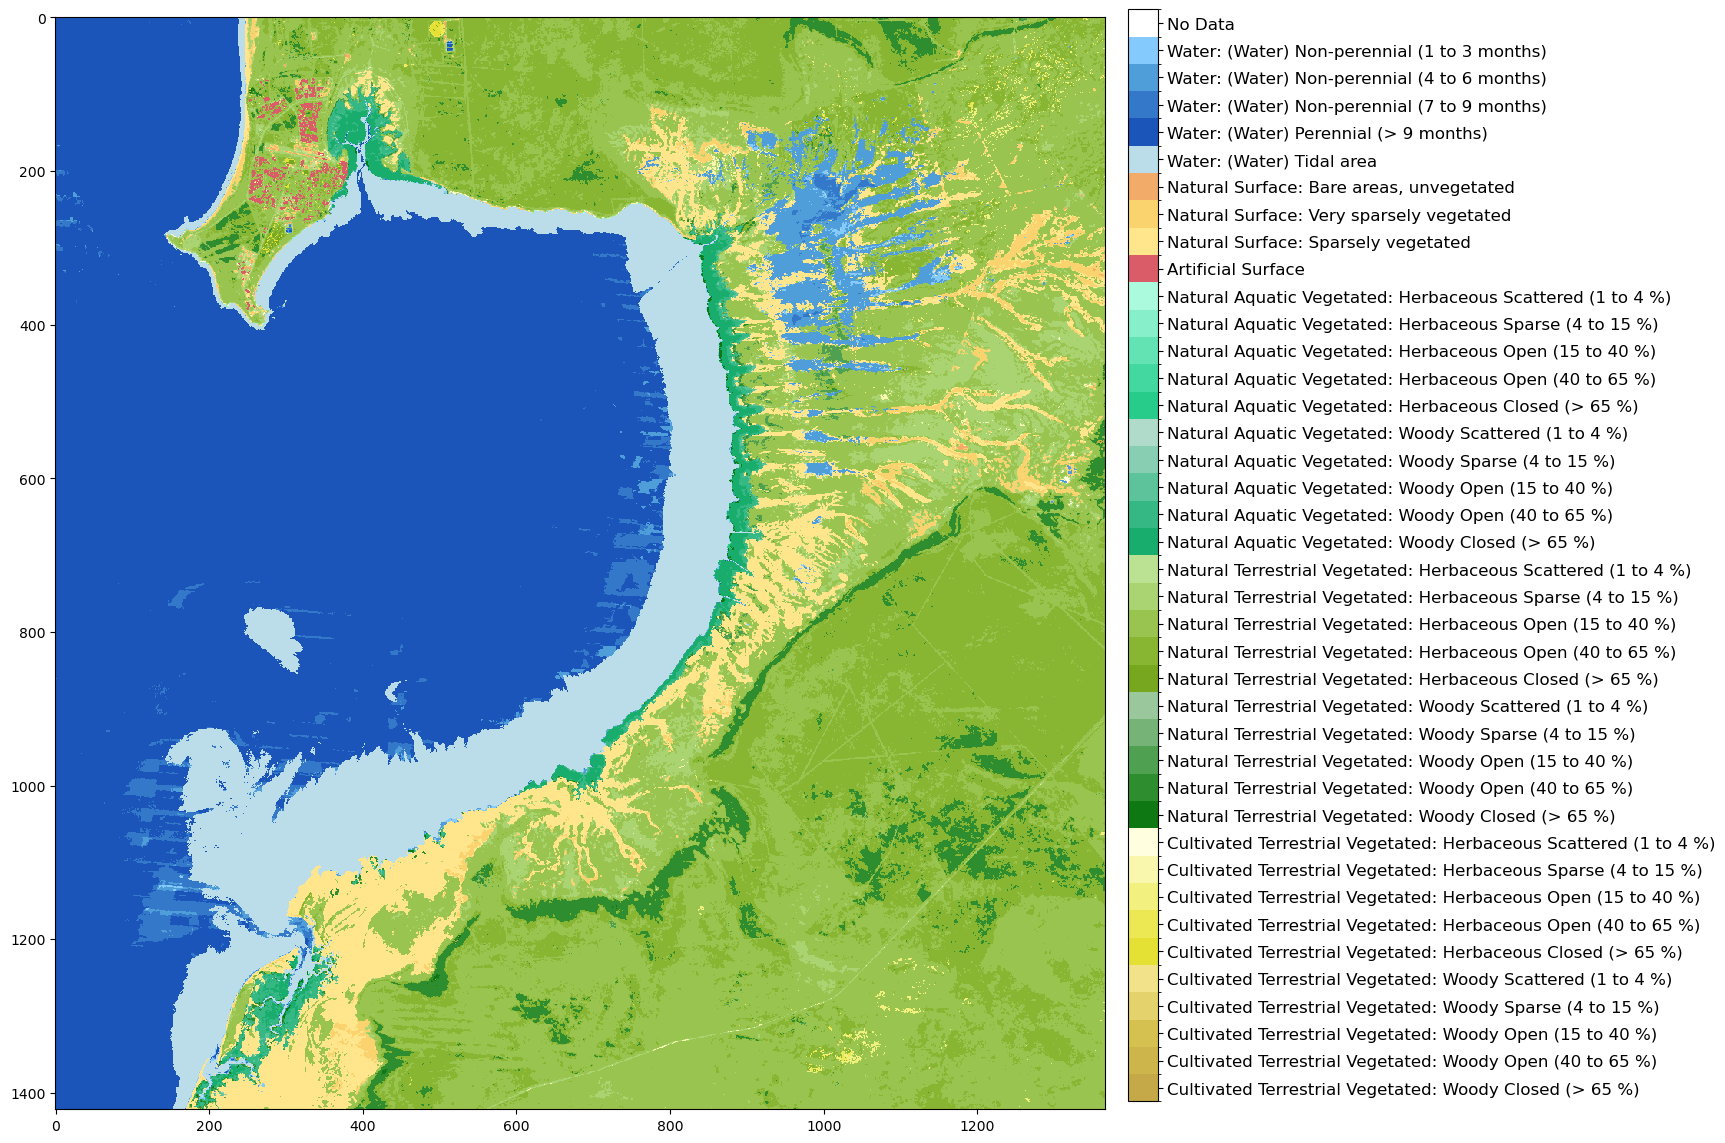

In [19]:
plot_land_cover(lc.level4, year='2017')

## Next steps

There are several supplementary notebooks in this repository that demonstrate different DEA Land Cover data visualisation and analysis functions:

* [**DEA Land Cover animations**](../How_to_guides/Land_cover_animated_plots.ipynb) – create customisable land cover animations, with the option to include an adjacent stacked line plot.
* [**DEA Land Cover pixel drill**](../How_to_guides/Land_cover_pixel_drill.ipynb) – graph the history of a pixel by creating a pixel drill plot. 
* [**DEA Land Cover change mapping**](../How_to_guides/Land_cover_change_mapping.ipynb) – visualise change by creating a change map between 2 discrete years.  

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** February 2025

**Compatible datacube version:** 

In [20]:
print(datacube.__version__)

1.8.19


## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->